## 1.0 Project Objective

Find the optimal position to place 6 ambulances within a day (3 hour interval) in which they will travel the least amount of distance.

Additional Notes
- Each ambulance is committed every three hours
- Ambulances travel within allocated "sectors"

## 2.0 Out Approach 

The accidents identify areas where an ambulance must reach. 
We will 

We will:
- Use K-Means Clustering to find the cluster centroids, and assume these are the central points for the accidents.  
- create a voronoi diagram which helps us visualize the central point of these accidents

Further, we will want to : 
- visualize the accident points
- time distribution of accidents

In [3]:
# load required libraries
import pandas as pd
import numpy as np
import geopandas as gpd
import datetime as dt

import matplotlib.pyplot as plt
import time     

# processing geojson files
from geovoronoi import voronoi_regions_from_coords, points_to_coords

# clustering + visualisation
from sklearn.cluster import KMeans
import seaborn as sns

from scipy.spatial import Voronoi, voronoi_plot_2d

### 2.1 Explore Our Data 

In [4]:
df = pd.read_csv('Train.csv', parse_dates=['datetime'])
print(df.shape)
df.head()

(6318, 4)


,uid,datetime,latitude,longitude
0,1,2018-01-01 00:25:46,-1.188850,36.931382
1,2,2018-01-01 02:02:39,-0.662939,37.208730
2,3,2018-01-01 02:31:49,-0.662939,37.208730
3,4,2018-01-01 03:04:01,-1.288087,36.826583
4,5,2018-01-01 03:58:49,-1.188850,36.931382


Text(0.5, 1.0, 'Accident Locations Around Nairobi')

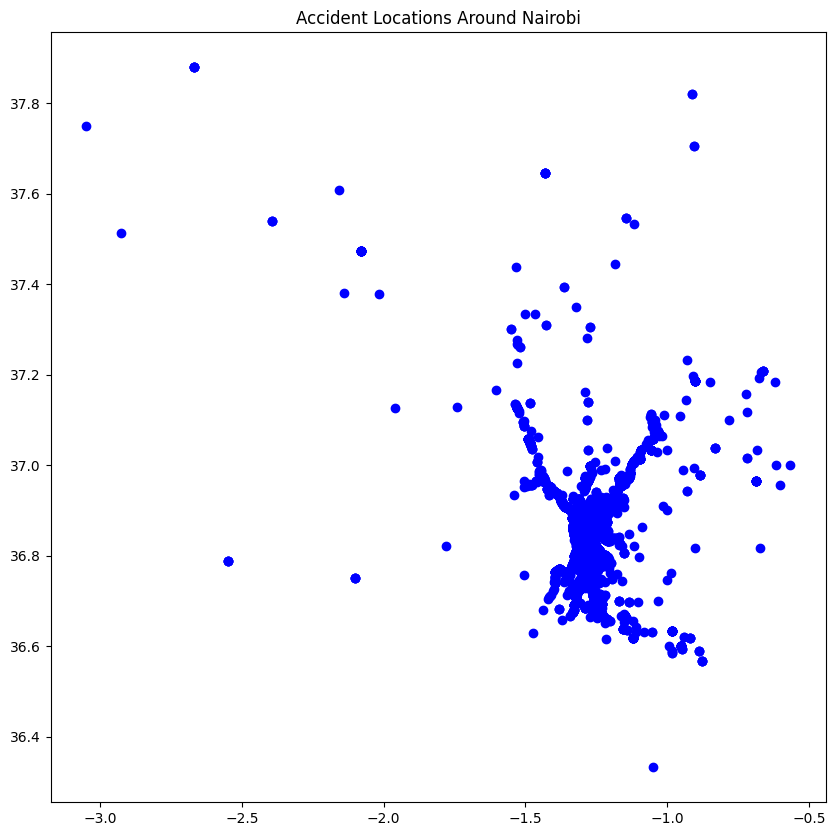

In [6]:
plt.figure(figsize=(10,10))
plt.scatter(df['latitude'],df['longitude'],marker="o",c='blue')
plt.title('Accident Locations Around Nairobi')


### 2.2 Create Temporal Features and Sub-set the data based on different time durations

C:\Users\DE737AP\AppData\Local\Temp\ipykernel_24268\587578798.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_month = df.resample('M', on='datetime')['idx'].count().reset_index()
C:\Users\DE737AP\AppData\Local\Temp\ipykernel_24268\587578798.py:17: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_3hours = df.resample('3H', on='datetime')['idx'].count().reset_index()


Text(0.5, 1.0, 'Accident Distribution per 3Hours')

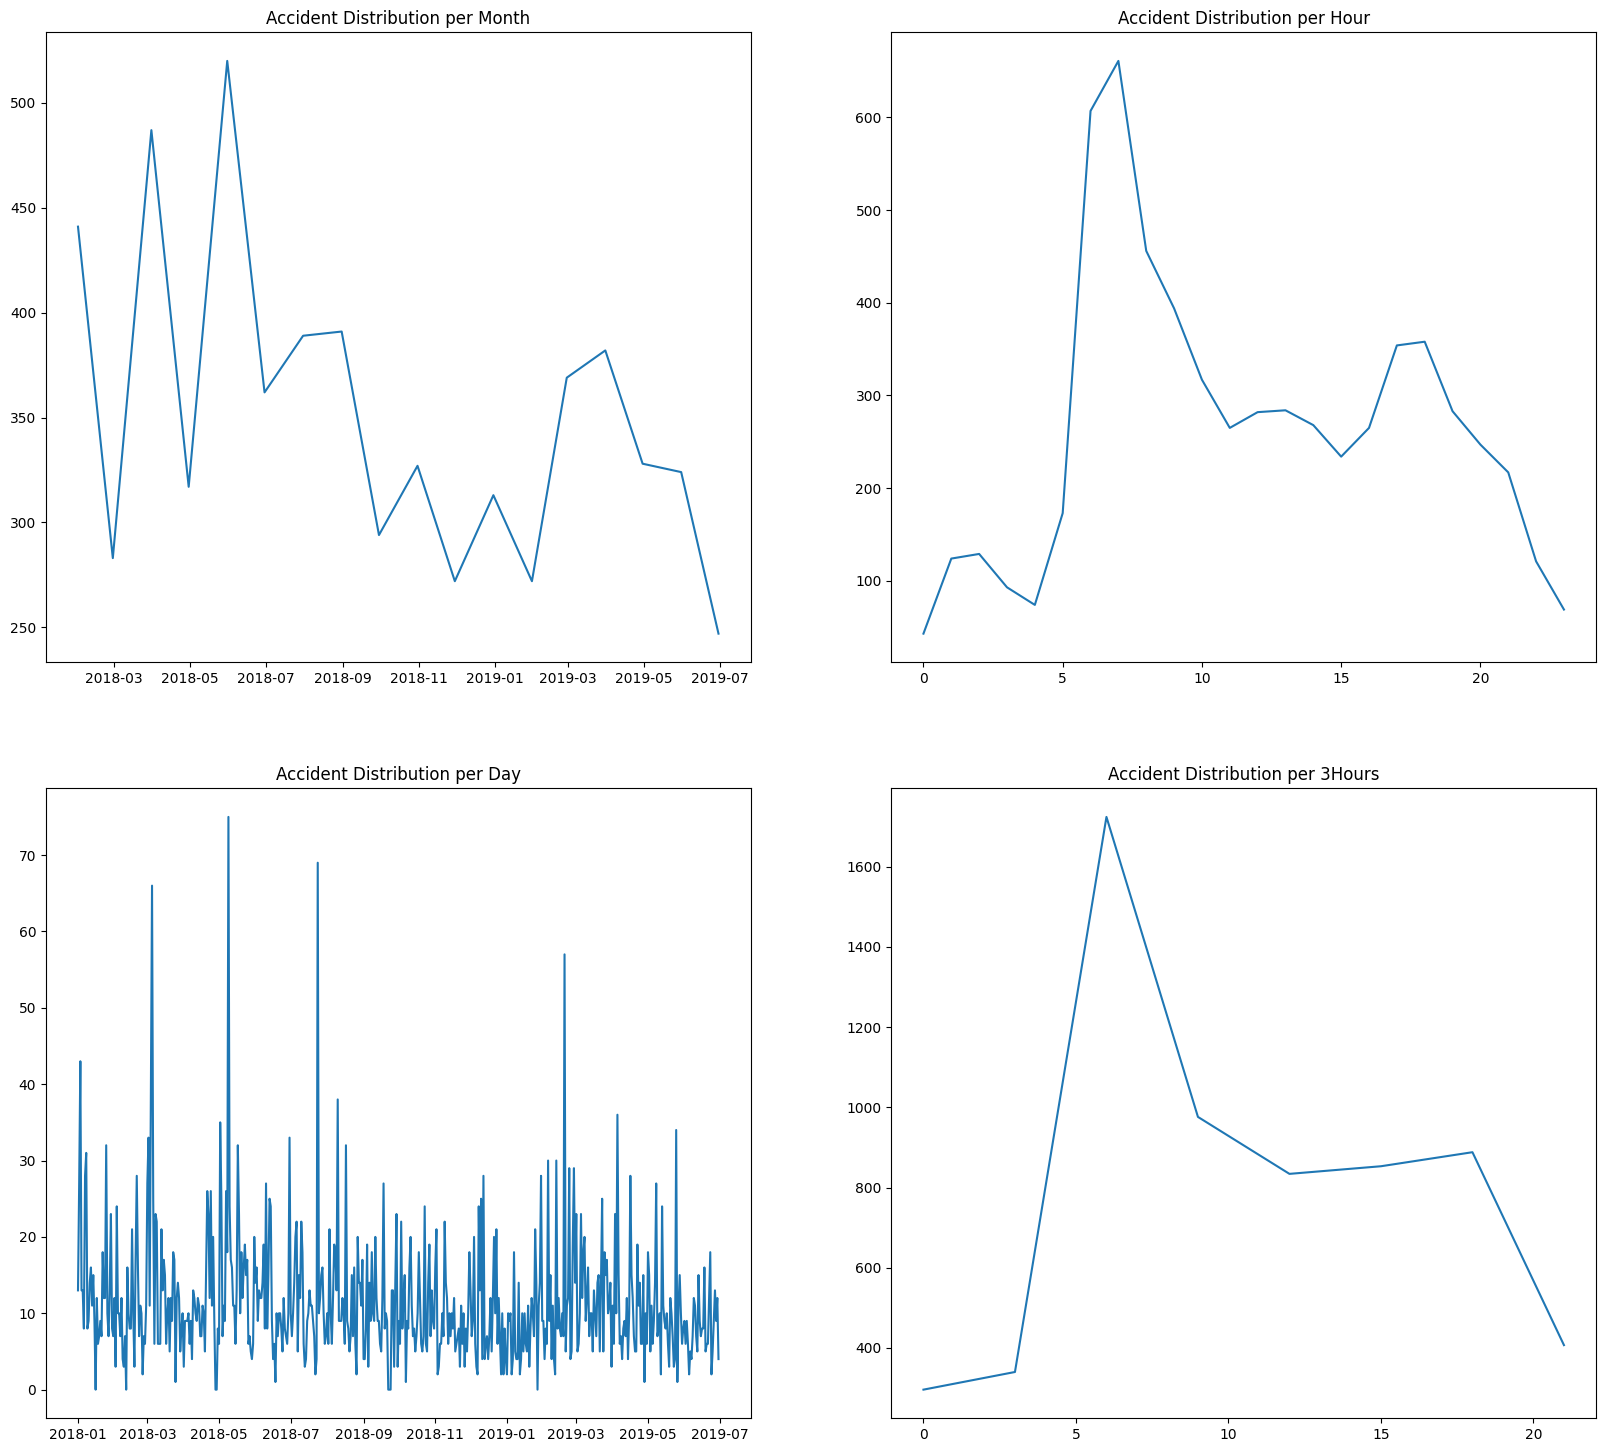

In [ ]:

## per month
df['idx'] = 1
df['hour'] = df['datetime'].dt.hour

df_month = df.resample('M', on='datetime')['idx'].count().reset_index()
df_pd_month = pd.DataFrame(df_month)

## per day
df_day = df.resample('D', on='datetime')['idx'].count().reset_index()
df_pd_day = pd.DataFrame(df_day)

## per hour
df_hour = df.groupby('hour').count().reset_index()
df_pd_hour = pd.DataFrame(df_hour)

## per 3 hours
df_3hours = df.resample('3H', on='datetime')['idx'].count().reset_index()
df_3hours['datetime'] = df_3hours['datetime'].dt.hour

df_3hours = df_3hours.groupby('datetime').sum().reset_index()
df_pd_3hours = pd.DataFrame(df_3hours)

#---- axes
x_day = df_pd_day['datetime']
y_day = df_pd_day['idx']

x_month = df_pd_month['datetime']
y_month = df_pd_month['idx']

x_hour = df_pd_hour['hour']
y_hour = df_pd_hour['idx']

x_3hours = df_pd_3hours['datetime']
y_3hours = df_pd_3hours['idx']

fig, axs = plt.subplots(2, 2,figsize=(20, 18))

axs[0, 0].plot(x_month, y_month)
axs[0, 0].set_title("Accident Distribution per Month")

axs[1, 0].plot(x_day, y_day)
axs[1, 0].set_title("Accident Distribution per Day")

axs[0, 1].plot(x_hour, y_hour)
axs[0, 1].set_title("Accident Distribution per Hour")

axs[1, 1].plot(x_3hours, y_3hours)
axs[1, 1].set_title("Accident Distribution per 3Hours")

On a daily basis there is very little variance on accident reports apart from time to time spike, however on a three hourly basis, the variation is evident and when modelling we need to take keen interest of this

In [9]:
df.head()

,uid,datetime,latitude,longitude,idx,hour
0,1,2018-01-01 00:25:46,-1.188850,36.931382,1,0
1,2,2018-01-01 02:02:39,-0.662939,37.208730,1,2
2,3,2018-01-01 02:31:49,-0.662939,37.208730,1,2
3,4,2018-01-01 03:04:01,-1.288087,36.826583,1,3
4,5,2018-01-01 03:58:49,-1.188850,36.931382,1,3


### 2.2 Clustering


#### 2.2.1 Clustering without Regard for time

C:\Users\DE737AP\AppData\Local\Temp\ipykernel_24268\245672730.py:25: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[1,0].scatter(centers[:, 0], centers[:, 1], s=200, alpha=1,cmap='viridis')


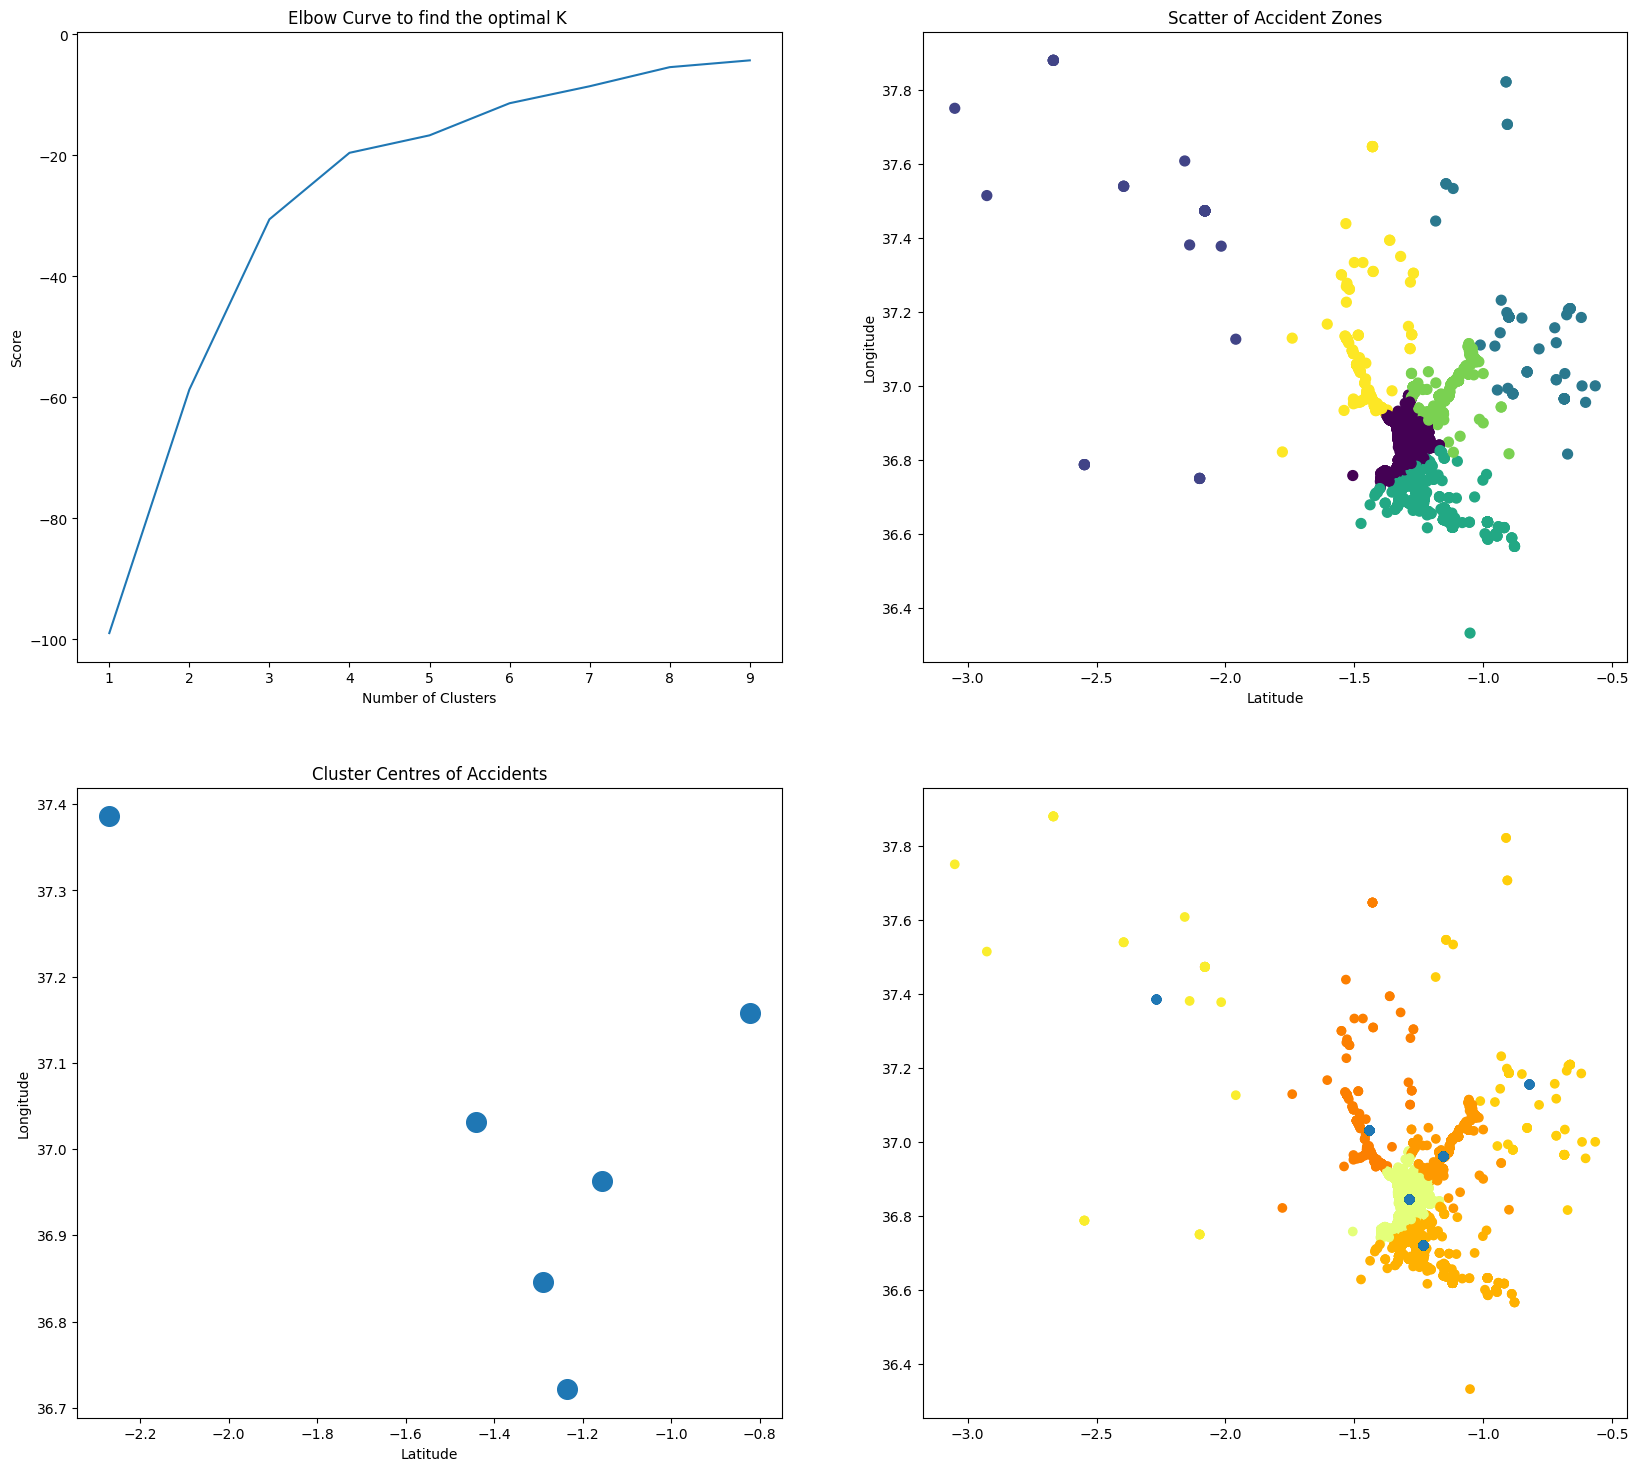

In [12]:
# custering the accidents
K_clusters = range(1,10)

kmeans = [KMeans(n_clusters=i) for i in K_clusters]

Y_axis = df[['latitude']]
X_axis = df[['longitude']]

score = [kmeans[i].fit(Y_axis).score(Y_axis) for i in range(len(kmeans))]
# Variable with the Longitude and Latitude
X=df.loc[:,['datetime','latitude','longitude']]

kmeans = KMeans(n_clusters = 6, init ='k-means++')
kmeans.fit(X[X.columns[1:3]]) # Compute k-means clustering.
X['cluster_label'] = kmeans.fit_predict(X[X.columns[1:3]])
centers = kmeans.cluster_centers_ # Coordinates of cluster centers.
labels = kmeans.predict(X[X.columns[1:3]]) # Labels of each point

fig, axs = plt.subplots(2, 2,figsize=(20, 18))
axs[0, 0].plot(K_clusters, score)
axs[0, 0].set_title('Elbow Curve to find the optimal K ')
axs[0, 0].set_ylabel('Score')
axs[0, 0].set_xlabel('Number of Clusters')

axs[1,0].scatter(centers[:, 0], centers[:, 1], s=200, alpha=1,cmap='viridis')
axs[1, 0].set_title('Cluster Centres of Accidents')
axs[1, 0].set_ylabel('Longitude')
axs[1, 0].set_xlabel('Latitude')

axs[0,1].scatter(x = X['latitude'], y = X['longitude'], c=labels, s=50, cmap='viridis')
axs[0, 1].set_title('Scatter of Accident Zones')
axs[0, 1].set_ylabel('Longitude')
axs[0, 1].set_xlabel('Latitude')

## super impose the centers on the clusters
points = pd.DataFrame([centers[:, 0], centers[:, 1]]).transpose()
points.reset_index(inplace=True)
points['cluster_label']=points.index
result=pd.merge(X,points,
               how='left')

axs[1,1].scatter(result['latitude'],result['longitude'],c=result['cluster_label'],cmap='Wistia')
axs[1,1].scatter(result[0],result[1])

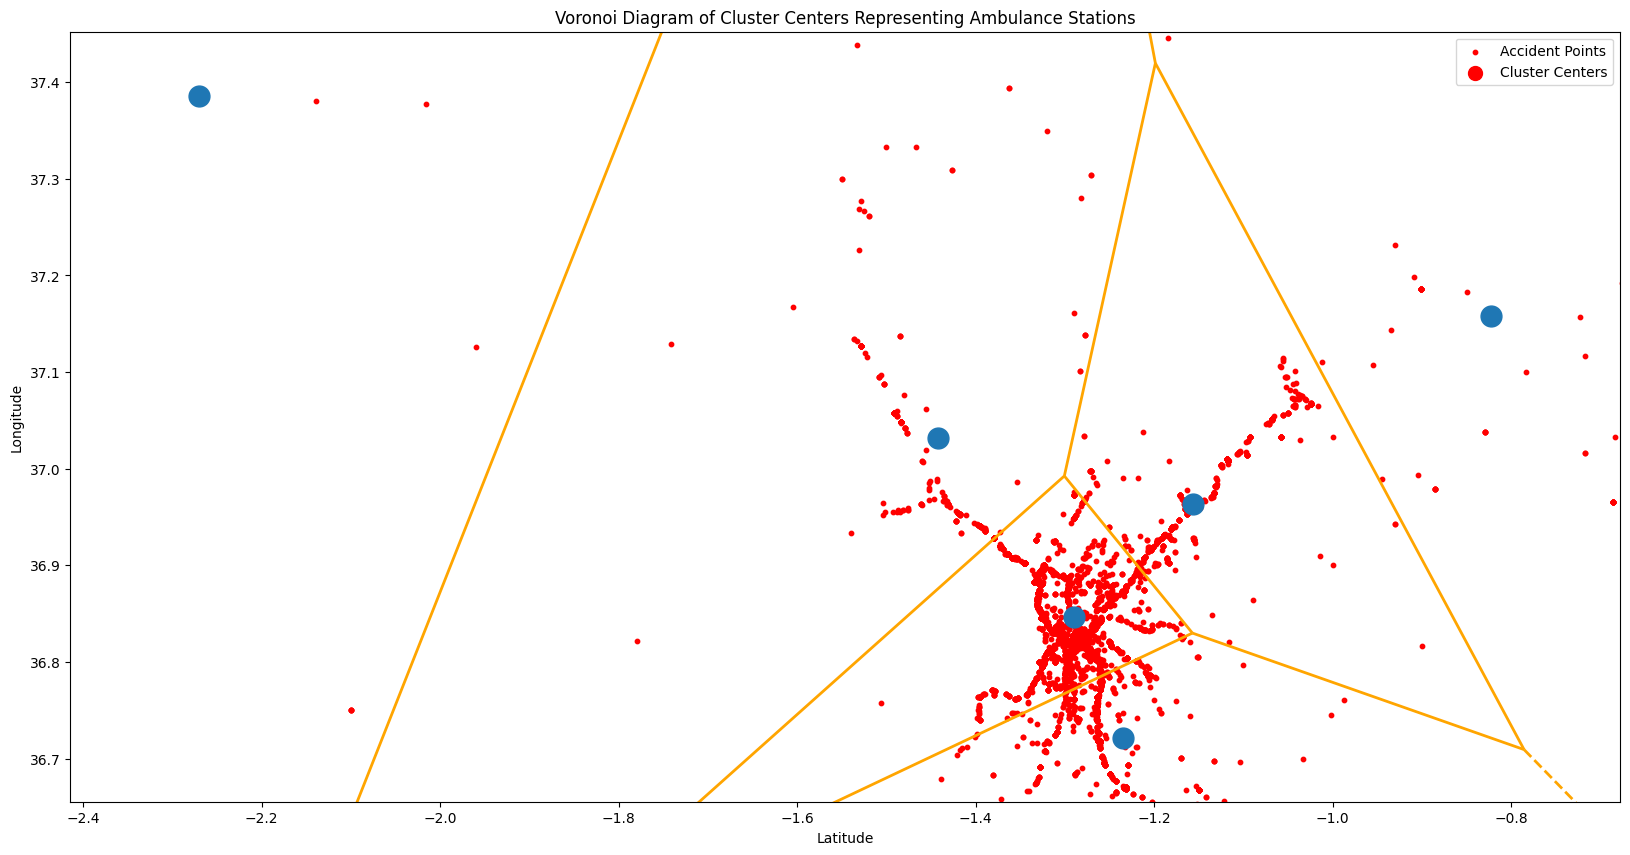

In [26]:
# Create Voronoi diagram for cluster centers
vor = Voronoi(centers)
fig_vor, ax_vor = plt.subplots(figsize=(20, 10))
voronoi_plot_2d(vor, ax=ax_vor, show_vertices=False, line_colors='orange', line_width=2, point_size=30)
ax_vor.scatter(df['latitude'], df['longitude'], c='red', s=10, label='Accident Points')
ax_vor.scatter(centers[:, 0], centers[:, 1], c='red', s=100, marker='o', label='Cluster Centers')
ax_vor.set_title('Voronoi Diagram of Cluster Centers Representing Ambulance Stations')
ax_vor.set_xlabel('Latitude')
ax_vor.set_ylabel('Longitude')
ax_vor.legend()
plt.show()

#### 2.2.2 Define a Scoring Function to calculate the minimum distance to be traveled by an ambulance

In [ ]:
# define a scoring function
def score_ambulance(sub, ref):
    total_distance = 0
    for date, c_lat, c_lon in ref[['datetime', 'latitude', 'longitude']].values:
        row = sub.loc[sub.date < date].tail(1)
        dists = []
        for a in range(6):
            dist = ((c_lat - row[f'A{a}_Latitude'].values[0])**2+(c_lon - row[f'A{a}_Longitude'].values[0])**2)**0.5
            dists.append(dist)
        total_distance += min(dists)
    return total_distance

# Test set
reference = df.loc[df.datetime > '2019-01-01'] # Using 2019 as our test set

# Date range covering test set
dates = pd.date_range('2019-01-01', '2020-01-01', freq='3h')


In [14]:
## use this clustering to get ambulance locations

# Create submission dataframe
sub = pd.DataFrame({
    'date':dates
})
for ambulance in range(6):
    sub['A'+str(ambulance)+'_Latitude'] = centers.tolist()[ambulance][0]
    sub['A'+str(ambulance)+'_Longitude'] = centers.tolist()[ambulance][1]
sub.head()


,date,A0_Latitude,A0_Longitude,A1_Latitude,A1_Longitude,A2_Latitude,A2_Longitude,A3_Latitude,A3_Longitude,A4_Latitude,A4_Longitude,A5_Latitude,A5_Longitude
0,2019-01-01 00:00:00,-1.289466,36.846118,-2.269933,37.385892,-0.822568,37.15758,-1.235118,36.72177,-1.15676,36.963245,-1.442209,37.031394
1,2019-01-01 03:00:00,-1.289466,36.846118,-2.269933,37.385892,-0.822568,37.15758,-1.235118,36.72177,-1.15676,36.963245,-1.442209,37.031394
2,2019-01-01 06:00:00,-1.289466,36.846118,-2.269933,37.385892,-0.822568,37.15758,-1.235118,36.72177,-1.15676,36.963245,-1.442209,37.031394
3,2019-01-01 09:00:00,-1.289466,36.846118,-2.269933,37.385892,-0.822568,37.15758,-1.235118,36.72177,-1.15676,36.963245,-1.442209,37.031394
4,2019-01-01 12:00:00,-1.289466,36.846118,-2.269933,37.385892,-0.822568,37.15758,-1.235118,36.72177,-1.15676,36.963245,-1.442209,37.031394


In [15]:
score_ambulance(sub,reference)

np.float64(118.02518670715206)

#### 2.2.3 Now cluster with time in mind


In [16]:
def flaten(centers_list):
    """flatening the list of tuples [(x0,y0),(x1,y1),(x2,y2),(x3,y3)] to [x0,y0,x1,y1,x2,y2,x3,y3]"""
    merged = list(zip(centers_list[:,0],centers_list[:,1]))
    return [c for couple in merged for c in couple ]

loop throught [0,3,6,9,12,15,18,21] to split the training dataset into 8 chunks based on the hours of the crushes and create separate data sets then create seperated models based on those datasets

In [18]:
for i in range(0,22,3):
    d = df[(df['datetime'].dt.hour>=i) & (df['datetime'].dt.hour<=i+3)]
    kmeans = KMeans(n_clusters=6, random_state=0).fit(d[['latitude','longitude']])
    t = flaten(kmeans.cluster_centers_)
    sub.loc[sub['date'].dt.hour == i, ['A0_Latitude','A0_Longitude',
                                     'A1_Latitude','A1_Longitude','A2_Latitude','A2_Longitude',
                                     'A3_Latitude','A3_Longitude','A4_Latitude','A4_Longitude',
                                     'A5_Latitude','A5_Longitude']] = t

sub.head()

,date,A0_Latitude,A0_Longitude,A1_Latitude,A1_Longitude,A2_Latitude,A2_Longitude,A3_Latitude,A3_Longitude,A4_Latitude,A4_Longitude,A5_Latitude,A5_Longitude
0,2019-01-01 00:00:00,-1.251440,36.832428,-2.667570,37.879490,-0.982937,37.044342,-1.339559,36.880901,-1.414685,37.363440,-2.157872,37.607692
1,2019-01-01 03:00:00,-1.278856,36.800261,-2.667570,37.879490,-1.663896,37.210919,-1.335417,36.893553,-1.180214,36.927889,-1.061520,36.631557
2,2019-01-01 06:00:00,-1.358907,36.925228,-1.230807,36.883019,-2.272487,37.384144,-1.063313,37.113370,-1.287228,36.784686,-1.059127,36.641069
3,2019-01-01 09:00:00,-1.285797,36.789437,-2.282399,37.312977,-1.254813,36.890540,-1.026252,36.620439,-1.023643,37.049588,-1.422403,36.985458
4,2019-01-01 12:00:00,-1.271196,36.781998,-1.213099,36.900110,-1.941905,37.501344,-0.671822,37.007523,-1.346320,36.902539,-1.019748,37.119817


In [21]:
sub.to_csv('submission_1.csv',index=False)

## 3.0 Make the Submission to Zindi and Check Score